# Abhängige und unabhängige Stichproben – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/abh%C3%A4ngige-und-unabh%C3%A4ngige-stichproben)

Ob eine Stichprobe **abhängig** oder **unabhängig** ist, entscheidet darüber,
welcher **Hypothesentest** verwendet wird.

| | **Unabhängige Stichproben** | **Abhängige Stichproben** |
|---|---|---|
| **Merkmal** | Verschiedene Personen in jeder Gruppe | Dieselben Personen in mehreren Messungen |
| **Synonym** | Ungepaart | Gepaart, Messwiederholung |
| **Datenpaar?** | Nein | Ja – jede Person hat ≥ 2 Messwerte |
| **t-Test** | t-Test für unabh. Stichproben | t-Test für abh. Stichproben |
| **ANOVA** | Varianzanalyse ohne MWH | Varianzanalyse mit MWH |
| **Nicht-parametrisch** | Mann-Whitney-U / Kruskal-Wallis | Wilcoxon / Friedman |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Der Kernunterschied

### Unabhängige Stichproben
- Jede Person erscheint **nur in einer** Gruppe
- Kein inhaltlicher Zusammenhang zwischen den Messwerten der Gruppen
- **Beispiele:**
  - Männer vs. Frauen (Einkommen)
  - Kontrollgruppe vs. Treatmentgruppe (verschiedene Personen)
  - Kunden aus Stadt A vs. Kunden aus Stadt B

### Abhängige Stichproben
- Dieselbe Person (oder ein **natürliches Paar**) liefert Messwerte in **mehreren** Gruppen
- Messwerte liegen **paarweise** vor
- **Beispiele:**
  - Stresslevel **vor** und **nach** dem Urlaub (dieselbe Person!)
  - Baseballschläger A vs. B – dieselben Spieler testen beide
  - Gartenarbeit: jeweils Mann + Frau **einer Beziehung** (natürliches Paar)

In [13]:
# numiqo-Beispiel: Stresslevel vor und nach dem Urlaub
np.random.seed(42)
n = 20

# Szenario 1: Unabhängige Stichproben – ANDERE Personen vor/nach
stress_vorher_unabh  = pd.Series(np.random.normal(65, 12, n), name="Vorher")
stress_nachher_unabh = pd.Series(np.random.normal(52, 11, n), name="Nachher")

# Szenario 2: Abhängige Stichproben – DIESELBEN Personen vor/nach
stress_vorher_abh    = pd.Series(np.random.normal(65, 12, n), name="Vorher")
# Individuelle Effekte: Jede Person hat eigenen Basiswert
individuelle_effekte = stress_vorher_abh + np.random.normal(-13, 5, n)
stress_nachher_abh   = pd.Series(individuelle_effekte.clip(0, 100), name="Nachher")

print("Szenario 1: Unabhängige Stichproben")
print(f"Gruppe 'Vorher':  n={n}, MW={stress_vorher_unabh.mean():.1f}, SD={stress_vorher_unabh.std():.1f}")
print(f"Gruppe 'Nachher': n={n}, MW={stress_nachher_unabh.mean():.1f}, SD={stress_nachher_unabh.std():.1f}")
print()
print("Szenario 2: Abhängige Stichproben")
print(f"Messung 'Vorher':  n={n}, MW={stress_vorher_abh.mean():.1f}, SD={stress_vorher_abh.std():.1f}")
print(f"Messung 'Nachher': n={n}, MW={stress_nachher_abh.mean():.1f}, SD={stress_nachher_abh.std():.1f}")

# Daten als DataFrame (abhängig)
df_abh = pd.DataFrame({
    "Person":    range(1, n+1),
    "Vorher":    stress_vorher_abh.round(1).values,
    "Nachher":   stress_nachher_abh.round(1).values,
})
df_abh["Differenz"] = (df_abh["Nachher"] - df_abh["Vorher"]).round(1)
print()
print("Abhängige Daten – erste 8 Zeilen (paarweise Messwerte):")
print(df_abh.head(8).to_string(index=False))

Szenario 1: Unabhängige Stichproben
Gruppe 'Vorher':  n=20, MW=62.9, SD=11.5
Gruppe 'Nachher': n=20, MW=49.1, SD=10.6

Szenario 2: Abhängige Stichproben
Messung 'Vorher':  n=20, MW=64.7, SD=9.9
Messung 'Nachher': n=20, MW=51.5, SD=10.4

Abhängige Daten – erste 8 Zeilen (paarweise Messwerte):
 Person  Vorher  Nachher  Differenz
      1    73.9     58.5      -15.4
      2    67.1     53.1      -14.0
      3    63.6     45.1      -18.5
      4    61.4     42.4      -19.0
      5    47.3     38.3       -9.0
      6    56.4     50.1       -6.3
      7    59.5     46.1      -13.4
      8    77.7     69.7       -8.0


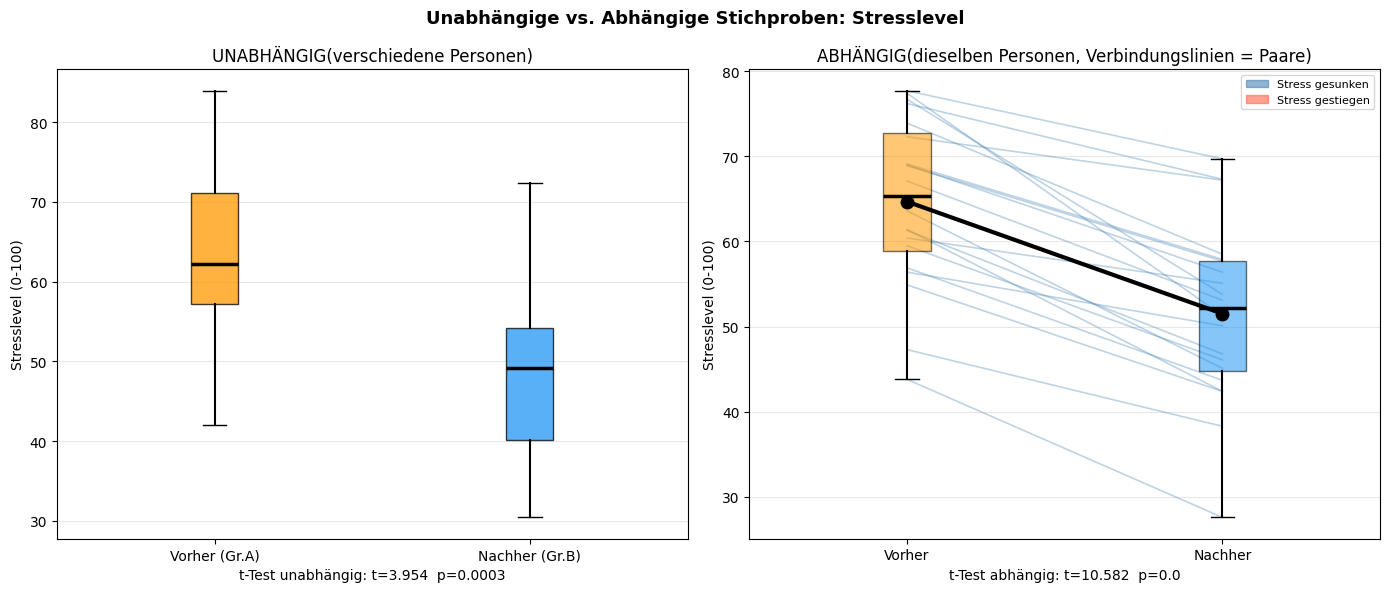

Vergleich der p-Werte:
  t-Test unabäengig: p = 0.0003
  t-Test abhängig:   p = 0.0000

Der abhängige t-Test ist sensitiver, weil er die individuelle
Variabilität zwischen Personen herausrechnet!


In [ ]:
# Visualisierung: Unabhängig vs. Abhängig
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Unabhängige vs. Abhängige Stichproben: Stresslevel",
             fontsize=13, fontweight="bold")

# Links: Unabhängige Stichproben
ax = axes[0]
bp = ax.boxplot([stress_vorher_unabh, stress_nachher_unabh],
                patch_artist=True,
                medianprops=dict(color="black", linewidth=2.5),
                whiskerprops=dict(linewidth=1.5))
farben = ["#FF9800", "#2196F3"]
for patch, fc in zip(bp["boxes"], farben):
    patch.set_facecolor(fc)
    patch.set_alpha(0.75)

# Kein Verbindungslinienpaar = unabhängig
ax.set_title("UNABHÄNGIG(verschiedene Personen)")
ax.set_ylabel("Stresslevel (0-100)")
ax.set_xticks([1, 2])
ax.set_xticklabels(["Vorher (Gr.A)", "Nachher (Gr.B)"])
ax.grid(axis="y", alpha=0.3)
t_u, p_u = stats.ttest_ind(stress_vorher_unabh, stress_nachher_unabh)
ax.set_xlabel("t-Test unabhängig: t=" + str(round(t_u, 3)) +
              "  p=" + str(round(p_u, 4)))

# Rechts: Abhängige Stichproben mit Verbindungslinien
ax2 = axes[1]
# Individuelle Verbindungslinien
for i in range(n):
    farbe = "steelblue" if df_abh["Differenz"].iloc[i] < 0 else "tomato"
    ax2.plot([1, 2], [df_abh["Vorher"].iloc[i], df_abh["Nachher"].iloc[i]],
             color=farbe, alpha=0.35, linewidth=1.2)

# Mittelwertlinie
ax2.plot([1, 2], [stress_vorher_abh.mean(), stress_nachher_abh.mean()],
         "o-", color="black", linewidth=3, markersize=9, zorder=5,
         label="Mittelwert")

bp2 = ax2.boxplot([stress_vorher_abh, stress_nachher_abh],
                  patch_artist=True,
                  medianprops=dict(color="black", linewidth=2.5),
                  whiskerprops=dict(linewidth=1.5))
for patch, fc in zip(bp2["boxes"], farben):
    patch.set_facecolor(fc)
    patch.set_alpha(0.55)

ax2.set_title("ABHÄNGIG(dieselben Personen, Verbindungslinien = Paare)")
ax2.set_ylabel("Stresslevel (0-100)")
ax2.set_xticks([1, 2])
ax2.set_xticklabels(["Vorher", "Nachher"])
ax2.grid(axis="y", alpha=0.3)
t_a, p_a = stats.ttest_rel(stress_vorher_abh, stress_nachher_abh)
ax2.set_xlabel("t-Test abhängig: t=" + str(round(t_a, 3)) +
               "  p=" + str(round(p_a, 4)))

blau_pf = mpatches.Patch(color="steelblue", alpha=0.6, label="Stress gesunken")
rot_pf  = mpatches.Patch(color="tomato",    alpha=0.6, label="Stress gestiegen")
ax2.legend(handles=[blau_pf, rot_pf], fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

print("Vergleich der p-Werte:")
print(f"  t-Test unabäengig: p = {p_u:.4f}")
print(f"  t-Test abhängig:   p = {p_a:.4f}")
print()
print("Der abhängige t-Test ist sensitiver, weil er die individuelle")
print("Variabilität zwischen Personen herausrechnet!")

## 2. Warum die Unterscheidung entscheidend ist

**Falscher Test → falsche Schlussfolgerung!**

Der **abhängige t-Test** rechnet die **interindividuelle Varianz** heraus, die nicht
mit der Treatmentwirkung zusammenhängt. Dadurch wird der Test **sensitiver**.

### Standardfehler im Vergleich

| | Unabhängiger t-Test | Abhängiger t-Test |
|---|---|---|
| **Teststatistik basiert auf** | Differenz der Gruppenmittelwerte | Mittelwert der **Differenzen** je Person |
| **Standardfehler** | $\sqrt{s_1^2/n_1 + s_2^2/n_2}$ | $s_d / \sqrt{n}$ |
| **Vorteil Abhängig** | — | Interindividuelle Streuung eliminiert |

Warum abhängiger t-Test sensitiver ist
MW Vorher:       55.87
MW Nachher:      49.05
MW Differenz:    -6.82
SD Vorher:       19.68  (grosse interindiv. Streuung!)
SD Nachher:      18.97
SD Differenz:    3.06  (viel kleiner!)

t-Test unabhängig: t=1.222, p=0.2276 -> NICHT signifikant
t-Test abhängig:   t=10.928,  p=0.000000 -> signifikant

Fazit: Obwohl der Effekt real ist (-8 Punkte), findet der unabhängige
t-Test ihn möglicherweise NICHT - weil die interindividuelle Varianz
den Effekt 'verdeckt'. Der abhängige Test rechnet sie heraus.


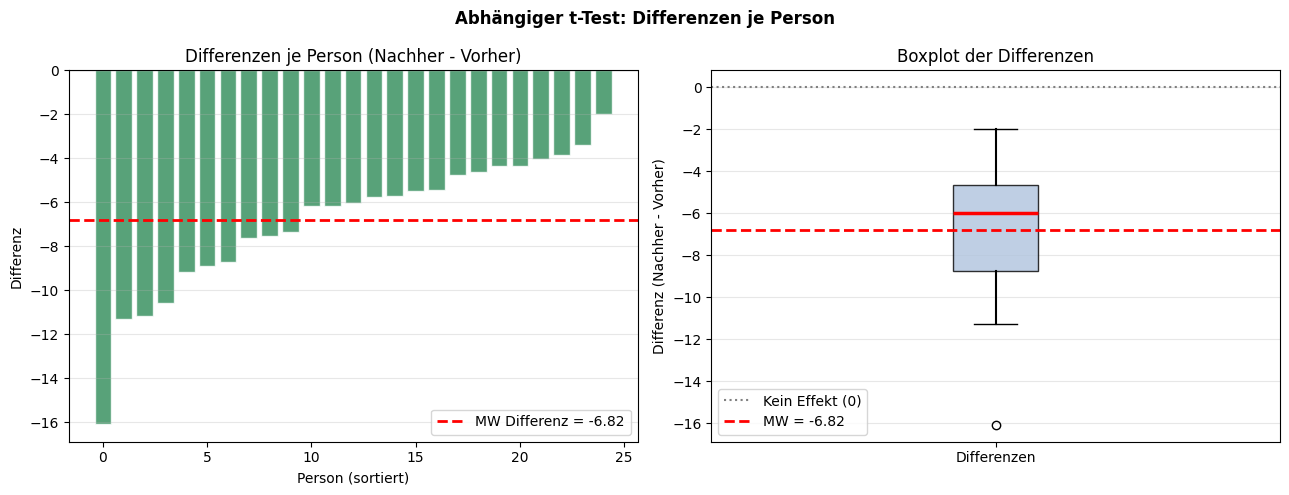

In [20]:
# Demonstration: Warum der abhängige t-Test sensitiver ist
np.random.seed(42)
n_demo = 25

# Individuelle Basiswerte (Personen unterscheiden sich stark)
basiswerte = np.random.normal(60, 20, n_demo)  # grosse interindiv. Varianz

# Treatment-Effekt: jede Person verbessert sich um ca. 8 Punkte
vorher = basiswerte + np.random.normal(0, 3, n_demo)
nachher = basiswerte + np.random.normal(-8, 3, n_demo)  # ca. -8 Punkte

differenzen = nachher - vorher

print("Warum abhängiger t-Test sensitiver ist")
print(f"MW Vorher:       {vorher.mean():.2f}")
print(f"MW Nachher:      {nachher.mean():.2f}")
print(f"MW Differenz:    {differenzen.mean():.2f}")
print(f"SD Vorher:       {vorher.std():.2f}  (grosse interindiv. Streuung!)")
print(f"SD Nachher:      {nachher.std():.2f}")
print(f"SD Differenz:    {differenzen.std():.2f}  (viel kleiner!)")
print()

t_unabh, p_unabh = stats.ttest_ind(vorher, nachher)
t_abh,   p_abh   = stats.ttest_rel(vorher, nachher)

print(f"t-Test unabhängig: t={t_unabh:.3f}, p={p_unabh:.4f} "
      + ("-> signifikant" if p_unabh < 0.05 else "-> NICHT signifikant"))
print(f"t-Test abhängig:   t={t_abh:.3f},  p={p_abh:.6f} "
      + ("-> signifikant" if p_abh < 0.05 else "-> NICHT signifikant"))
print()
print("Fazit: Obwohl der Effekt real ist (-8 Punkte), findet der unabhängige")
print("t-Test ihn möglicherweise NICHT - weil die interindividuelle Varianz")
print("den Effekt 'verdeckt'. Der abhängige Test rechnet sie heraus.")

# Visualisierung der Differenzen
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Abhängiger t-Test: Differenzen je Person", fontsize=12, fontweight="bold")

# Individuelle Differenzen
farben_d = ["seagreen" if d < 0 else "tomato" for d in differenzen]
axes[0].bar(range(n_demo), sorted(differenzen), color=sorted(farben_d,
    key=lambda x: differenzen[farben_d.index(x)] if x in farben_d else 0),
    edgecolor="white", alpha=0.8)
axes[0].axhline(0, color="black", linewidth=1.5)
axes[0].axhline(differenzen.mean(), color="red", linestyle="--", linewidth=2,
                label="MW Differenz = " + str(round(differenzen.mean(), 2)))
axes[0].set_title("Differenzen je Person (Nachher - Vorher)")
axes[0].set_xlabel("Person (sortiert)")
axes[0].set_ylabel("Differenz")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Boxplots der Differenzen
axes[1].boxplot(differenzen, patch_artist=True,
                boxprops=dict(facecolor="lightsteelblue", alpha=0.8),
                medianprops=dict(color="red", linewidth=2.5),
                whiskerprops=dict(linewidth=1.5))
axes[1].axhline(0, color="gray", linestyle=":", linewidth=1.5,
                label="Kein Effekt (0)")
axes[1].axhline(differenzen.mean(), color="red", linestyle="--", linewidth=2,
                label="MW = " + str(round(differenzen.mean(), 2)))
axes[1].set_title("Boxplot der Differenzen")
axes[1].set_ylabel("Differenz (Nachher - Vorher)")
axes[1].set_xticklabels(["Differenzen"])
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Datenstruktur: Wie sehen die Daten aus?

Die Datenstruktur verrät oft sofort, ob es sich um abhängige oder unabhängige Stichproben handelt.

### Unabhängige Stichproben
```
Person | Gruppe    | Stresslevel
1      | Gruppe A  | 72
2      | Gruppe A  | 58
3      | Gruppe B  | 51     <- andere Personen!
4      | Gruppe B  | 63
```

### Abhängige Stichproben (Wide Format – paarweise)
```
Person | Vorher | Nachher
1      | 72     | 58      <- dieselbe Person!
2      | 65     | 49
3      | 80     | 71
```

### Abhängige Stichproben (Long Format)
```
Person | Zeitpunkt | Stresslevel
1      | Vorher    | 72
1      | Nachher   | 58      <- Person 1 taucht zweimal auf!
2      | Vorher    | 65
2      | Nachher   | 49
```

In [16]:
# Datenstruktur demonstrieren
np.random.seed(7)
n_str = 6

# Unabhängige Stichproben – Long Format
df_unabh = pd.DataFrame({
    "Person":     list(range(1, n_str+1)) + list(range(n_str+1, 2*n_str+1)),
    "Gruppe":     ["Gruppe A"]*n_str + ["Gruppe B"]*n_str,
    "Stresslevel": np.concatenate([
        np.random.normal(65, 10, n_str).round(1),
        np.random.normal(52, 10, n_str).round(1)
    ])
})

# Abhängige Stichproben – Wide Format
df_abh_wide = pd.DataFrame({
    "Person":  range(1, n_str+1),
    "Vorher":  np.random.normal(65, 10, n_str).round(1),
})
df_abh_wide["Nachher"] = (df_abh_wide["Vorher"] + np.random.normal(-12, 4, n_str)).round(1)
df_abh_wide["Differenz"] = (df_abh_wide["Nachher"] - df_abh_wide["Vorher"]).round(1)

# Long Format konvertieren
df_abh_long = df_abh_wide[["Person","Vorher","Nachher"]].melt(
    id_vars="Person", var_name="Zeitpunkt", value_name="Stresslevel"
).sort_values(["Person","Zeitpunkt"]).reset_index(drop=True)

print("UNABHÄNGIGE Stichproben (Long Format)")
print(df_unabh.to_string(index=False))
print()
print("ABHÄNGIGE Stichproben (Wide Format)")
print(df_abh_wide.to_string(index=False))
print()
print("ABHÄNGIGE Stichproben (Long Format)")
print(df_abh_long.to_string(index=False))

UNABHÄNGIGE Stichproben (Long Format)
 Person   Gruppe  Stresslevel
      1 Gruppe A         81.9
      2 Gruppe A         60.3
      3 Gruppe A         65.3
      4 Gruppe A         69.1
      5 Gruppe A         57.1
      6 Gruppe A         65.0
      7 Gruppe B         52.0
      8 Gruppe B         34.5
      9 Gruppe B         62.2
     10 Gruppe B         58.0
     11 Gruppe B         45.7
     12 Gruppe B         50.3

ABHÄNGIGE Stichproben (Wide Format)
 Person  Vorher  Nachher  Differenz
      1    70.1     59.2      -10.9
      2    62.4     44.3      -18.1
      3    62.6     57.2       -5.4
      4    50.5     39.1      -11.4
      5    70.5     57.0      -13.5
      6    66.2     62.3       -3.9

ABHÄNGIGE Stichproben (Long Format)
 Person Zeitpunkt  Stresslevel
      1   Nachher         59.2
      1    Vorher         70.1
      2   Nachher         44.3
      2    Vorher         62.4
      3   Nachher         57.2
      3    Vorher         62.6
      4   Nachher         39.

## 4. Mehr als zwei Gruppen

Auch bei mehr als zwei Gruppen gilt dieselbe Unterscheidung:

| Gruppen | Unabhängig | Abhängig |
|---|---|---|
| **2 Gruppen** | t-Test unabhängig | t-Test abhängig |
| **3+ Gruppen metrisch** | ANOVA ohne Messwiederholung | ANOVA mit Messwiederholung |
| **3+ Gruppen ordinal** | Kruskal-Wallis | Friedman-Test |

**Beispiel mit 3 Messpunkten (abhängig):**
Stresslevel **vor, während und nach** dem Urlaub – dieselben Personen.

3 abhängige Stichproben: Stresslevel
Vorher:    MW=61.4, SD=13.9
Während:  MW=57.3, SD=13.2
Nachher:   MW=47.3, SD=14.6
Friedman-Test: chi2=33.600, p=0.000000
-> Signifikanter Unterschied ueber die Zeit


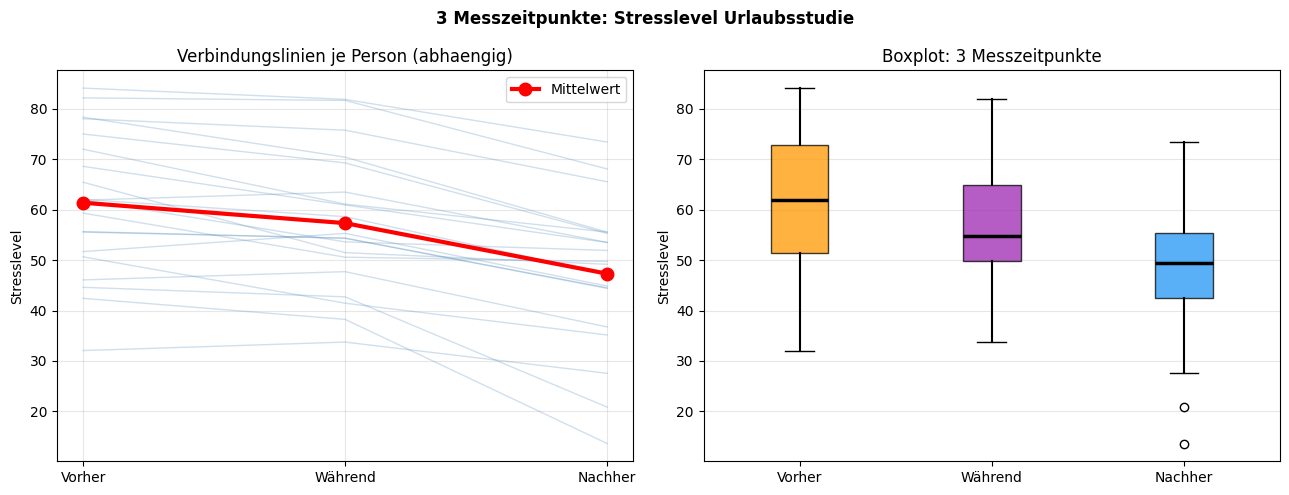

In [ ]:
# Mehr als 2 abhängige Gruppen: 3 Messzeitpunkte
np.random.seed(42)
n_3 = 20

# Dieselben Personen zu 3 Zeitpunkten
basiswerte_3 = np.random.normal(65, 15, n_3)
t1 = basiswerte_3 + np.random.normal(0,  4, n_3)   # Vorher
t2 = basiswerte_3 + np.random.normal(-5, 4, n_3)   # Während
t3 = basiswerte_3 + np.random.normal(-15,4, n_3)   # Nachher

print("3 abhängige Stichproben: Stresslevel")
print(f"Vorher:    MW={t1.mean():.1f}, SD={t1.std():.1f}")
print(f"Während:  MW={t2.mean():.1f}, SD={t2.std():.1f}")
print(f"Nachher:   MW={t3.mean():.1f}, SD={t3.std():.1f}")

# Friedman-Test (nichtparametrisch, abhängig, 3 Gruppen)
from scipy.stats import friedmanchisquare
stat_f, p_f = friedmanchisquare(t1, t2, t3)
print(f"Friedman-Test: chi2={stat_f:.3f}, p={p_f:.6f}")
print("-> " + ("Signifikanter Unterschied ueber die Zeit" if p_f < 0.05
               else "Kein signifikanter Unterschied"))

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("3 Messzeitpunkte: Stresslevel Urlaubsstudie", fontsize=12, fontweight="bold")

zeitpunkte = ["Vorher", "Während", "Nachher"]

# Verbindungslinien je Person
for i in range(n_3):
    axes[0].plot([0, 1, 2], [t1[i], t2[i], t3[i]],
                 color="steelblue", alpha=0.25, linewidth=1)

# Mittelwerte
mws = [t1.mean(), t2.mean(), t3.mean()]
axes[0].plot([0, 1, 2], mws, "o-", color="red", linewidth=3,
             markersize=9, zorder=5, label="Mittelwert")
axes[0].set_title("Verbindungslinien je Person (abhängig)")
axes[0].set_ylabel("Stresslevel")
axes[0].set_xticks([0, 1, 2])
axes[0].set_xticklabels(zeitpunkte)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot
bp3 = axes[1].boxplot([t1, t2, t3], patch_artist=True,
                       medianprops=dict(color="black", linewidth=2.5),
                       whiskerprops=dict(linewidth=1.5))
farb3 = ["#FF9800", "#9C27B0", "#2196F3"]
for patch, fc in zip(bp3["boxes"], farb3):
    patch.set_facecolor(fc)
    patch.set_alpha(0.75)
axes[1].set_title("Boxplot: 3 Messzeitpunkte")
axes[1].set_ylabel("Stresslevel")
axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels(zeitpunkte)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# Entscheidungshilfe: Welcher Test?
print("ENTSCHEIDUNGSHILFE: Welcher Test?")
print()

szenarien = [
    ("Männer vs. Frauen: Einkommen",
     "1 kategorisch (2 Gruppen) + 1 metrisch",
     "unabhängig",
     "t-Test unabhängig"),
    ("Stresslevel VOR und NACH Urlaub (dieselben Personen)",
     "2 metrische Messungen, paarweise",
     "abhängig",
     "t-Test abhängig"),
    ("3 Stadte: Gesundheitsbewusstsein",
     "1 kategorisch (3 Gruppen) + 1 metrisch",
     "unabhängig",
     "ANOVA ohne Messwiederholung"),
    ("Stresslevel VOR / WÄHREND / NACH Urlaub",
     "3 metrische Messungen, paarweise",
     "abhängig",
     "ANOVA mit Messwiederholung (oder Friedman)"),
    ("Schulnoten Raucher vs. Nichtraucher",
     "1 kategorisch (2 Gruppen) + 1 ordinal",
     "unabhängig",
     "Mann-Whitney-U-Test"),
    ("Befindlichkeit vor/nach Therapie (ordinal)",
     "2 ordinale Messungen, paarweise",
     "abhängig",
     "Wilcoxon-Test"),
]

for nr, (frage, variablen, typ, test) in enumerate(szenarien, 1):
    print(f"Beispiel {nr}: {frage}")
    print(f"  Variablen:  {variablen}")
    print(f"  Stichprobe: {typ}")
    print(f"  Test:       {test}")
    print()

ENTSCHEIDUNGSHILFE: Welcher Test?

Beispiel 1: Männer vs. Frauen: Einkommen
  Variablen:  1 kategorisch (2 Gruppen) + 1 metrisch
  Stichprobe: unabhängig
  Test:       t-Test unabhängig

Beispiel 2: Stresslevel VOR und NACH Urlaub (dieselben Personen)
  Variablen:  2 metrische Messungen, paarweise
  Stichprobe: abhängig
  Test:       t-Test abhängig

Beispiel 3: 3 Stadte: Gesundheitsbewusstsein
  Variablen:  1 kategorisch (3 Gruppen) + 1 metrisch
  Stichprobe: unabhängig
  Test:       ANOVA ohne Messwiederholung

Beispiel 4: Stresslevel VOR / WÄHREND / NACH Urlaub
  Variablen:  3 metrische Messungen, paarweise
  Stichprobe: abhängig
  Test:       ANOVA mit Messwiederholung (oder Friedman)

Beispiel 5: Schulnoten Raucher vs. Nichtraucher
  Variablen:  1 kategorisch (2 Gruppen) + 1 ordinal
  Stichprobe: unabhängig
  Test:       Mann-Whitney-U-Test

Beispiel 6: Befindlichkeit vor/nach Therapie (ordinal)
  Variablen:  2 ordinale Messungen, paarweise
  Stichprobe: abhängig
  Test:       Wil

## 5. Zusammenfassung

```
Abhängige vs. Unabhängige Stichproben
│
├── UNABHÄNGIGE STICHPROBEN
│   ├── Verschiedene Personen in jeder Gruppe
│   ├── Kein Zusammenhang zwischen den Messwerten
│   ├── Synonym: ungepaart
│   ├── Datenstruktur: 1 Zeile = 1 Person, Gruppe als Spalte
│   └── Tests:
│       2 Gruppen metrisch:  t-Test unabhängig
│       2 Gruppen ordinal:   Mann-Whitney-U
│       3+ Gruppen metrisch: ANOVA ohne Messwiederholung
│       3+ Gruppen ordinal:  Kruskal-Wallis
│
├── ABHÄNGIGE STICHPROBEN
│   ├── Dieselben Personen in mehreren Messungen ODER natuerliche Paare
│   ├── Messwerte liegen paarweise vor
│   ├── Synonym: gepaart, Messwiederholung
│   ├── Datenstruktur: 1 Zeile = 1 Person mit mehreren Messwerten
│   └── Tests:
│       2 Gruppen metrisch:  t-Test abhängig
│       2 Gruppen ordinal:   Wilcoxon-Test
│       3+ Gruppen metrisch: ANOVA mit Messwiederholung
│       3+ Gruppen ordinal:  Friedman-Test
│
└── VORTEIL ABHÄNGIGER DESIGN
    Interindividuelle Variabilität wird herausgerechnet
    -> Höhere Teststärke (sensitiver fuer echte Effekte)
    -> Kleinere Stichprobe nötig
```

---
Quelle: [numiqo.de/tutorial/abhaengige-und-unabhaengige-stichproben](https://numiqo.de/tutorial/abh%C3%A4ngige-und-unabh%C3%A4ngige-stichproben)